# Exercise 1.3: Metropolis algorithm for the 2D Ising model (*total: 15 points*)

In [2]:
### Necessary Python libraries
import IPython
assert IPython.version_info[0] >= 3, "Your version of IPython is too old, please update it."
import numpy as np
import matplotlib.pyplot as plt
from numba import jit
import time
import metropolis
%matplotlib inline

In [3]:
### If you wish, you can import more libraries here

---

## Exercise 1.3-a (1pt)

Read through the file `metropolis.py`, which implements the Metropolis algorithm for the classical 2D Ising model 

\begin{equation*}
    H = - J \sum_{\langle i, j\rangle} \sigma_i \sigma_j
\end{equation*}

with $J \equiv 1$. The 2D Ising model has a critical point at 

\begin{equation*}
    T_c = 2 J /\ln(1 + \sqrt{2}) \approx 2.269.
\end{equation*}

Run the script. What is it plotting? Answer in the markdown cell below.

> **Hint:** To run the script, either run the command `python metropolis.py` from the console or call `metropolis.main()` in this notebook.


2.269185314213022


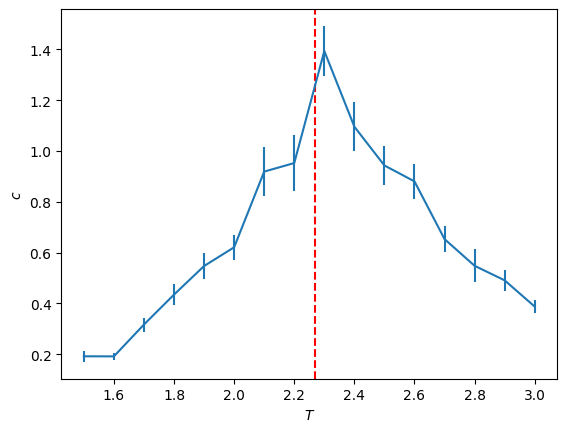

In [4]:
# YOUR CODE HERE
metropolis.main()

change of specific heat as temperature changes. It finds the "kink" to deduce the critical temperature. Red line is theoreticla value

---

## Exercise 1.3-b (3pt)

Plot some "typical" configurations at temperatures $T \gg T_c$, $T \approx T_c$ and $T \ll T_c$. What do you observe? Write your answer in the markdown cell below.

> **Hint:** To obtain a "typical" configuration at a temperature $T$, initialize the system randomly and then call `metropolis.metropolis_loop(system, T, N_sweeps, N_eq, N_flips, rng)` to run the simulation. You can plot a configuration using `matplotlib.pyplot.imshow(system)`.


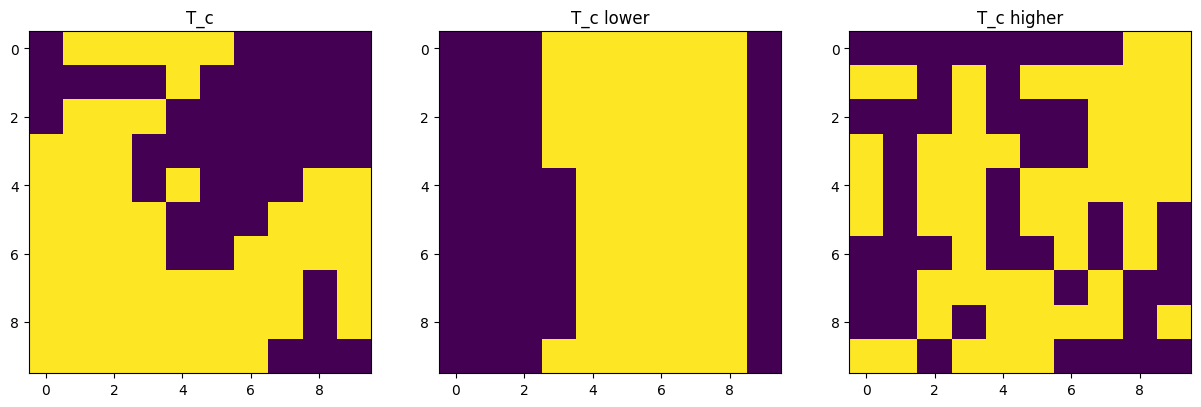

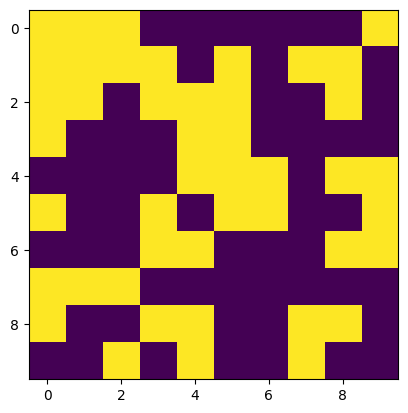

In [40]:
# YOUR CODE HERE
L = 10
rng = np.random.default_rng(112)
T_c = 2.269

fig, ax = plt.subplots(1,3,figsize=(15, 5))

system = metropolis.prepare_system(L, rng)
E_list = metropolis.metropolis_loop(system, T_c, 1000, 100, 10, rng)
ax[0].imshow(system)
ax[0].set_title("T_c")

system = metropolis.prepare_system(L, rng)
E_list = metropolis.metropolis_loop(system, T_c*0.05, 1000, 100, 10, rng)
ax[1].imshow(system)
ax[1].set_title("T_c lower")

system = metropolis.prepare_system(L, rng)
E_list = metropolis.metropolis_loop(system, T_c*100, 1000, 100, 10, rng)
ax[2].imshow(system)
ax[2].set_title("T_c higher")

plt.show()

system = metropolis.prepare_system(L, rng)
plt.imshow(system)
plt.show()


YOUR ANSWER HERE

---

## Exercise 1.3-c (4pt)

Plot the mean energy $E$ and mean specific heat $C_V$ versus temperature $T$ for different system sizes $L$. For both plots additionally plot errorbars.

> **Hint:** Use the function `metropolis.run(...)` to obtain the mean values and errors at a given system size $L$.


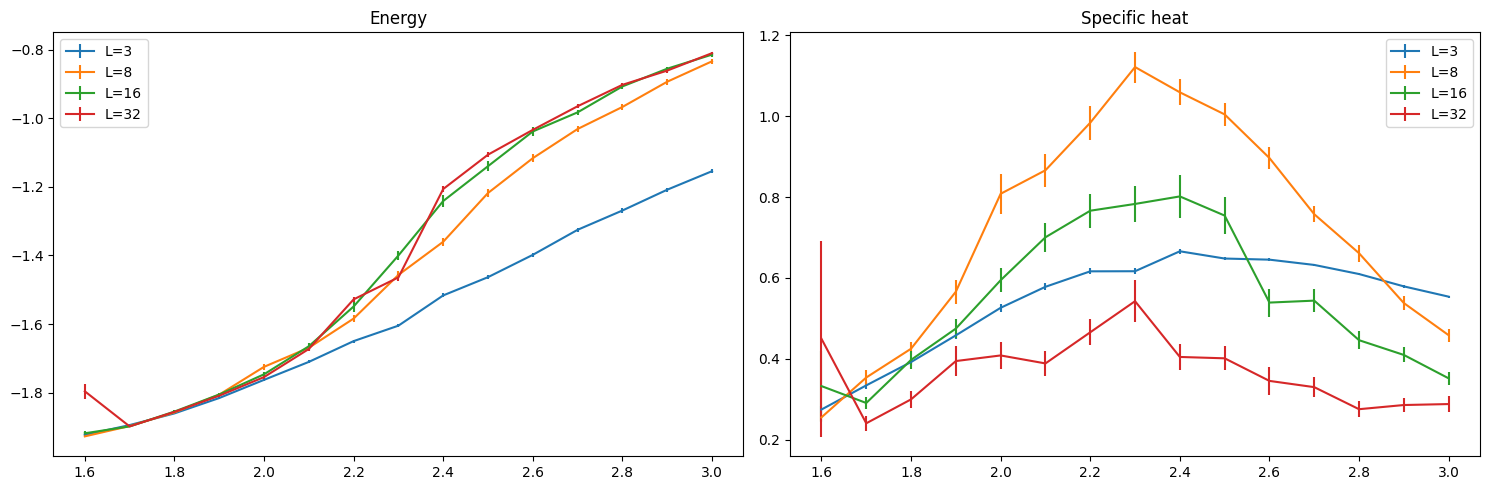

In [33]:
# YOUR CODE HERE
L_list = [3, 8, 16, 32]
rng = np.random.default_rng(112)

fig, ax = plt.subplots(1,2,figsize=(15, 5))

T_range = np.arange(1.6, 3.1, 0.1)
for L in L_list:
    E_list, C_list = metropolis.run(T_range=T_range, L=L, N_sweeps=10_000, N_eq=1_000, N_bins=50, N_flips=10, rng=rng)
    #ax[0].plot(T_range, E_list[:,0], label=f"L={L}")
    ax[0].errorbar(T_range, E_list[:,0], yerr=E_list[:,1], label=f"L={L}")
    #ax[1].plot(T_range, C_list[:,0], label=f"L={L}")
    ax[1].errorbar(T_range, C_list[:,0], yerr=C_list[:,1], label=f"L={L}")

ax[0].set_title("Energy")
ax[1].set_title("Specific heat")
ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()


---

## Exercise 1.3-d (3pt)

Write a new version of the `metropolis_loop(...)` function of the script with the necessary adjustments to also measure the magnetization 

\begin{equation*}
M = \frac{1}{L^2} \sum_{i} \sigma_{i}.
\end{equation*}

Plot how $M$ changes with simulation time (= the number of updates performed) for $T > T_c$, $T \approx T_c$ and $T < T_c$. Which time scales can you recognize? In which cases do you still get the correct expectation value $ \braket{M} = 0$? Write your answers in the markdown cell below.

> **Hint:** You can copy most of the code from `metropolis.metropolis_loop(...)` (you only need to add $2$ new lines of code to the function).


In [50]:
def metropolis_loop(system, T, N_sweeps, N_eq, N_flips, rng):
    """ Main loop doing the Metropolis algorithm. Measures the energy and magnetization."""
    # YOUR CODE HERE
    E = metropolis.measure_energy(system)
    L = system.shape[0]
    E_list = []
    M_list = []
    for step in range(N_sweeps + N_eq):
        i = rng.integers(0, L)
        j = rng.integers(0, L)

        dE = -2. * metropolis.energy(system, i, j, L)
        if dE <= 0.:
            system[i, j] *= -1
            E += dE
        elif np.exp(-1. / T * dE) > rng.random():
            system[i, j] *= -1
            E += dE

        if step >= N_eq and np.mod(step, N_flips) == 0:
            # measurement
            E_list.append(E)
            M_list.append(np.sum(system)/ (L ** 2))


    return np.array(E_list), np.array(M_list)

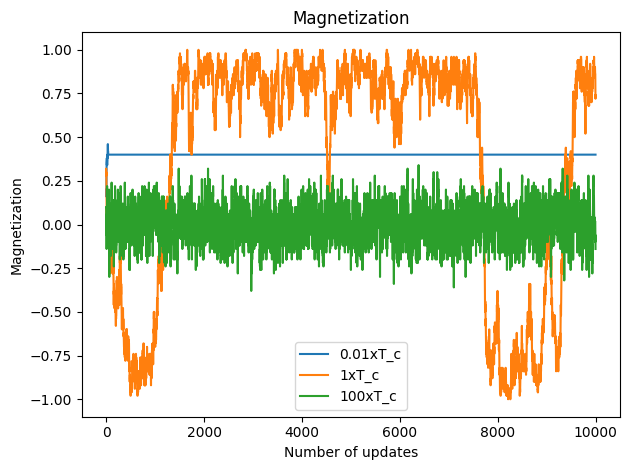

In [49]:
# YOUR CODE HERE
L = 10
rng = np.random.default_rng(1332)
a_list = [0.01, 1, 100]

for a in a_list:
    system = metropolis.prepare_system(L, rng)
    E_list, M_list = metropolis_loop(system, T_c * a, 100000, 100, 10, rng)
    plt.plot(list(range(len(M_list))), M_list, label = f"{a}xT_c")


plt.title("Magnetization")
plt.xlabel("Number of updates")
plt.ylabel("Magnetization")
plt.legend()
plt.tight_layout()
plt.show()


for Temperature higher than critical temperature, we get Magentization to be 0. for temperature lower than critical temperature the spins are practically fixed, so we have a frozen value of magentization. for temperature around critical temperature, there is a slow oscillation of magnetistaion. (Not sure about the time scale though) Long scale correltaion in the system. since the temperature is scalable to J, the bond between spins, the spins are sort of confused. For higher T, spins become independent as J becomes a small prize. no more correlation

---

## Exercise 1.3-e (2pt)

Write a new version of the `run(...)` function of the script, additionally measuring the magnetization and the absolute value of the magnetization ($\braket{|M|}$, i.e. taking the absolute value of $M$ before averaging). Plot $\braket{|M|}$ versus $T$ for different system sizes to see the transition.


In [ ]:
def run(T_range, L, N_sweeps, N_eq=None, N_bins=10, N_flips=10, rng=None):
    """
    run a monte carlo simulation for given system size, measuring the energy, specific heat, 
    magnetization, and absolute value of the magnetization.

    Paramaters
    ----------
    T_range : temperatures
    L : system size
    N_sweeps : number of steps for the measurements
    N_eq : number of equilibration steps. Defaults to N_sweeps/10.
    N_bins : number of bins used for the error analysis
    N_flips : number of updates between measurements.
    rng : Numpy (pseudo) random number generator.

    Returns
    -------
    E_list : energies (and errors) at the different temperatures
    C_list : specific heat (and errors) at the different temperatures
    M_list : magnetization (and errors) at the different temperatures
    M_abs_list : absolute value of the magnetization (and errors) at the different temperatures
    """
    # YOUR CODE HERE
    if N_eq is None:
        N_eq = N_sweeps//10  # integer division
    if rng is None:
        rng = np.random.default_rng()
    C_list = []
    E_list = []
    M_list = []
    system = prepare_system(L, rng)
    for T in T_range:
        C_list_bin = []
        E_list_bin = []
        for k in range(N_bins):
            # run N_sweeps metropolis updates and store results the array Es
            Es = metropolis_loop(system, T, N_sweeps, N_eq, N_flips, rng)
            # evaluate observables
            mean_E = np.mean(Es)
            mean_E2 = np.mean(Es**2)
            C_list_bin.append(1. / T**2. / L**2. * (mean_E2 - mean_E**2))
            E_list_bin.append(1. / L**2. * mean_E)
        # estimate error from binning analysis
        C_list.append([np.mean(C_list_bin), np.std(C_list_bin) / np.sqrt(N_bins)])
        E_list.append([np.mean(E_list_bin), np.std(E_list_bin) / np.sqrt(N_bins)])
    return np.array(E_list), np.array(C_list)

    return np.array(E_list), np.array(C_list), np.array(M_list), np.array(M_abs_list)

In [ ]:
# YOUR CODE HERE

---

## Exercise 1.3-f (2pt)

Include a magnetic field $h$ coupling to the spins with a term

\begin{equation*}
H^\prime = -h \sum_{i} \sigma_i.
\end{equation*}

Plot the specific heat and $\braket{|M|}$ versus $T$ for $L = 16$ and $h\in\{0, 0.05, 0.1\}.$


In [ ]:
# YOUR CODE HERE

---

## Bonus (optional)

Some further ideas for playing around (if you still have time):

* Instead of restarting from a random state for each new $\beta$, re-use the last state of the previous simulation. You should still perform sweeps without measurements for the thermalization. Is it better to start with large $\beta$ or small $\beta$?
* Change the lattice.
* Optimize the code.
* $\dots$